# SKIRTOR Torus Parameter Sensitivity Exploration

**Exploratory notebook, not part of the paper pipeline.** The paper's Type 1/Type 2 AGN
models use a single "average" SKIRTOR torus geometry (optical depth $\tau=7$, radial
gradient $p=0.5$, polar/vertical gradient $q=0$, opening angle $40^\circ$, radius ratio
$R=20$), varying *only* inclination ($30^\circ$ for Type 1, $70^\circ$ for Type 2) to
distinguish unobscured/obscured views (`src/config.py`'s `SKIRTOR_TYPE1_PARAMS`/
`SKIRTOR_TYPE2_PARAMS`). This notebook asks: how sensitive are the paper's headline
UVJ/IRAC results to that specific choice of the *other* torus parameters, versus
inclination?

**Design:** one-factor-at-a-time (OFAT) sensitivity sweep. For each of the two paper
inclinations (Type 1-like $i=30^\circ$, Type 2-like $i=70^\circ$), vary each of
$\tau$, $p$, $q$, and opening angle across its full SKIRTOR grid range, one parameter
at a time, holding the other three at the paper's reference value. The full SKIRTOR
grid (`glass.config.SKIRTOR_DIR`, 19,200 models) is bundled with GLASS, so every grid
point used here is a real, pre-computed radiative-transfer model, not an interpolation.
`radius_ratio` is not swept here (only 3 grid values, less commonly varied in the AGN
torus literature) but could be added later using the same pattern.

**Simplification vs. the actual paper pipeline:** IRAC colours here are evaluated
**rest-frame** ($z=0$), matching how the paper's own theoretical grid was evaluated
*before* the redshift-realism fix (see `notebooks/Model_Validation_via_IRAC.ipynb`),
not the real-redshift-bootstrapped approach the paper's actual Figure 1 now uses. This
is a deliberate simplification to keep this sensitivity sweep fast (~20 parameter
variants here vs. one AGN model in the paper); since every variant is evaluated the
SAME way, relative comparisons between parameter values remain meaningful even though
absolute completeness numbers won't match the paper's Figure 1 directly. If a specific
parameter turns out to matter enough to warrant an appendix figure, that panel should
be regenerated with the full redshift-realistic treatment before publication.

Uses the full 129-template Brown/GALSEDATLAS population (Section~\ref{subsec:...} of
the paper), same as every other theoretical-grid figure.


In [1]:
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from src import config
from glass import data_io, composite_math, photometry, analysis, visualization

visualization.apply_pasa_style()

t0 = time.time()
filters = photometry.load_passbands(config.FILTER_PATHS)
brown_templates, brown_names = data_io.read_brown_galaxy_templates(config.GALSEDATLAS_DIR)
print(f"[{time.time()-t0:.1f}s] loaded {len(brown_templates)} Brown templates + filters")

FRAC_AGN_GRID = np.array([0.0, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99])
ALPHA_EXT = FRAC_AGN_GRID / (1.0 - FRAC_AGN_GRID)

OUTPUT_DIR = os.path.join(config.PROCESSED_DATA_DIR, 'skirtor_sensitivity')
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Output directory:", OUTPUT_DIR)


[0.1s] loaded 129 Brown templates + filters
Output directory: C:\Users\uqmhooym\OneDrive - The University of Queensland\Documents\GitHub\HonoursResearchProject\outputs\skirtor_sensitivity


In [2]:
# Reference torus geometry (the paper's own "average AGN model", src/config.py) and
# the parameter grid each is swept over, read directly from the SKIRTOR file list
# rather than hardcoded, so this always matches whatever grid is actually bundled.
REFERENCE = {'optical_depth': 7, 'p': 0.5, 'q': 0, 'opening_angle': 40, 'radius_ratio': 20}
INCLINATIONS = {'Type1-like (i=30)': 30, 'Type2-like (i=70)': 70}

import re
_pattern = re.compile(r't([\d.]+)_p([\d.]+)_q([\d.]+)_oa([\d.]+)_R([\d.]+)_Mcl0\.97_i([\d.]+)_sed\.dat')
_files = [f for f in os.listdir(config.SKIRTOR_DIR) if f.endswith('_sed.dat')]
_grid_sets = {'optical_depth': set(), 'p': set(), 'q': set(), 'opening_angle': set()}
for f in _files:
    m = _pattern.match(f)
    if m:
        _grid_sets['optical_depth'].add(float(m.group(1)))
        _grid_sets['p'].add(float(m.group(2)))
        _grid_sets['q'].add(float(m.group(3)))
        _grid_sets['opening_angle'].add(float(m.group(4)))

def _fmt(x):
    return int(x) if float(x).is_integer() else x

PARAM_GRIDS = {name: sorted(vals) for name, vals in _grid_sets.items()}
for name, vals in PARAM_GRIDS.items():
    print(f"{name}: {vals}  (reference={REFERENCE[name]})")


optical_depth: [3.0, 5.0, 7.0, 9.0, 11.0]  (reference=7)
p: [0.0, 0.5, 1.0, 1.5]  (reference=0.5)
q: [0.0, 0.5, 1.0, 1.5]  (reference=0)
opening_angle: [10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0]  (reference=40)


In [3]:
def load_agn_model(param_overrides, inclination):
    '''Loads a SKIRTOR model at the reference geometry with one parameter
    overridden, at the given inclination.'''
    params = dict(REFERENCE)
    params.update(param_overrides)
    return data_io.read_skirtor_model(
        config.SKIRTOR_DIR,
        optical_depth=_fmt(params['optical_depth']), p=_fmt(params['p']), q=_fmt(params['q']),
        opening_angle=_fmt(params['opening_angle']), radius_ratio=_fmt(params['radius_ratio']),
        inclination=_fmt(inclination),
    )

def run_grid_for_agn(agn_model):
    '''UVJ + rest-frame IRAC colours for all 129 templates x the extended
    f_AGN grid, for one AGN model. Matches the pattern used throughout the
    paper's theoretical-grid notebooks (Model_Validation_via_IRAC.ipynb,
    Paper_Results_Master.ipynb), minus the redshift-realism step (see
    the intro markdown cell for why).'''
    rows = []
    for t_idx, gal_sed in enumerate(brown_templates):
        for f_agn, alpha in zip(FRAC_AGN_GRID, ALPHA_EXT):
            comp_sed = composite_math.create_composite_sed(agn_model, gal_sed, alpha)
            uv, vj = photometry.calculate_UVJ_colours(comp_sed, filters['U'], filters['V'], filters['J'])
            f5836, f8045 = photometry.calculate_irac_colours(
                comp_sed, filters['3.6'], filters['4.5'], filters['5.8'], filters['8.0'], redshift=0.0)
            rows.append({'Template': brown_names[t_idx], 'f_AGN': f_agn,
                         'U-V': uv, 'V-J': vj, 'f5836': f5836, 'f8045': f8045})
    return pd.DataFrame(rows)

def summarise(df):
    '''Per-f_AGN summary: IRAC Lacy-wedge completeness, mean IRAC vector
    offset (dex), mean UVJ vector offset (mag), and UVJ population fractions.'''
    out = []
    df0 = df[df['f_AGN'] == 0.0].set_index('Template')
    for f_agn in FRAC_AGN_GRID:
        sub = df[df['f_AGN'] == f_agn].set_index('Template').loc[df0.index]
        in_wedge = analysis.is_in_lacy_wedge(sub['f5836'].values, sub['f8045'].values)
        irac_offset = analysis.calculate_mean_vector_offset(
            sub['f5836'].values, sub['f8045'].values, df0['f5836'].values, df0['f8045'].values)
        uvj_offset = analysis.calculate_mean_vector_offset(
            sub['V-J'].values, sub['U-V'].values, df0['V-J'].values, df0['U-V'].values)
        cls = analysis.classify_uvj(sub['V-J'].values, sub['U-V'].values)
        q_frac, sf_frac, d_frac = analysis.calculate_population_fractions(cls)
        out.append({'f_AGN': f_agn, 'irac_completeness': in_wedge.mean(),
                     'irac_offset_dex': irac_offset, 'uvj_offset_mag': uvj_offset,
                     'quiescent_frac': q_frac, 'sf_frac': sf_frac, 'dusty_frac': d_frac,
                     'mean_UV': sub['U-V'].mean(), 'mean_VJ': sub['V-J'].mean()})
    return pd.DataFrame(out)


In [4]:
# Run the full OFAT sweep: for each inclination, for each parameter, for each
# grid value of that parameter (others held at REFERENCE), compute the full
# 129-template x f_AGN grid and summarise it. ~20 variants x 2 inclinations;
# each variant is a few hundred ms, so this completes in well under a minute.
results = {}  # (inclination_label, param_name, param_value) -> summary DataFrame
t0 = time.time()

for incl_label, incl in INCLINATIONS.items():
    for param_name, grid_values in PARAM_GRIDS.items():
        for value in grid_values:
            key = (incl_label, param_name, value)
            agn_model = load_agn_model({param_name: value}, incl)
            df_grid = run_grid_for_agn(agn_model)
            results[key] = summarise(df_grid)
    print(f"[{time.time()-t0:.1f}s] done: {incl_label}")

print(f"[{time.time()-t0:.1f}s] Sweep complete: {len(results)} (inclination, parameter, value) variants computed.")


[16.7s] done: Type1-like (i=30)


[33.7s] done: Type2-like (i=70)
[33.7s] Sweep complete: 42 (inclination, parameter, value) variants computed.


In [5]:
# Save the full sweep to a single long-format CSV for reuse (e.g. if a panel
# turns out to be worth an appendix figure later).
rows = []
for (incl_label, param_name, value), summary_df in results.items():
    d = summary_df.copy()
    d['inclination_label'] = incl_label
    d['param_name'] = param_name
    d['param_value'] = value
    rows.append(d)
full_sweep_df = pd.concat(rows, ignore_index=True)
full_sweep_df.to_csv(os.path.join(OUTPUT_DIR, 'skirtor_sensitivity_full.csv'), index=False)
print(f"Saved {len(full_sweep_df)} rows to skirtor_sensitivity_full.csv")
full_sweep_df.head()


Saved 504 rows to skirtor_sensitivity_full.csv


,f_AGN,irac_completeness,irac_offset_dex,uvj_offset_mag,quiescent_frac,sf_frac,dusty_frac,mean_UV,mean_VJ,inclination_label,param_name,param_value
0,0.00,0.178295,0.000000,0.000000,0.573643,0.356589,0.069767,1.605311,0.990856,Type1-like (i=30),optical_depth,3.0
1,0.01,0.178295,0.011855,0.010475,0.573643,0.356589,0.069767,1.595175,0.989752,Type1-like (i=30),optical_depth,3.0
2,0.10,0.372093,0.100975,0.102771,0.472868,0.410853,0.116279,1.506047,0.979227,Type1-like (i=30),optical_depth,3.0
3,0.20,0.519380,0.179534,0.204919,0.356589,0.488372,0.155039,1.407736,0.965933,Type1-like (i=30),optical_depth,3.0
4,0.30,0.736434,0.246604,0.310017,0.255814,0.604651,0.139535,1.306968,0.950343,Type1-like (i=30),optical_depth,3.0


## Sensitivity plots

One figure per diagnostic (IRAC Lacy-wedge completeness, IRAC vector offset, UVJ
vector offset), each a 4 (parameter) x 2 (inclination) grid of small multiples. Within
each panel, one line per grid value of that parameter (colour-graded from the
reference value), so a "sensitive" parameter shows lines fanning out strongly, while
an "insensitive" one shows lines that stay bunched together regardless of value.


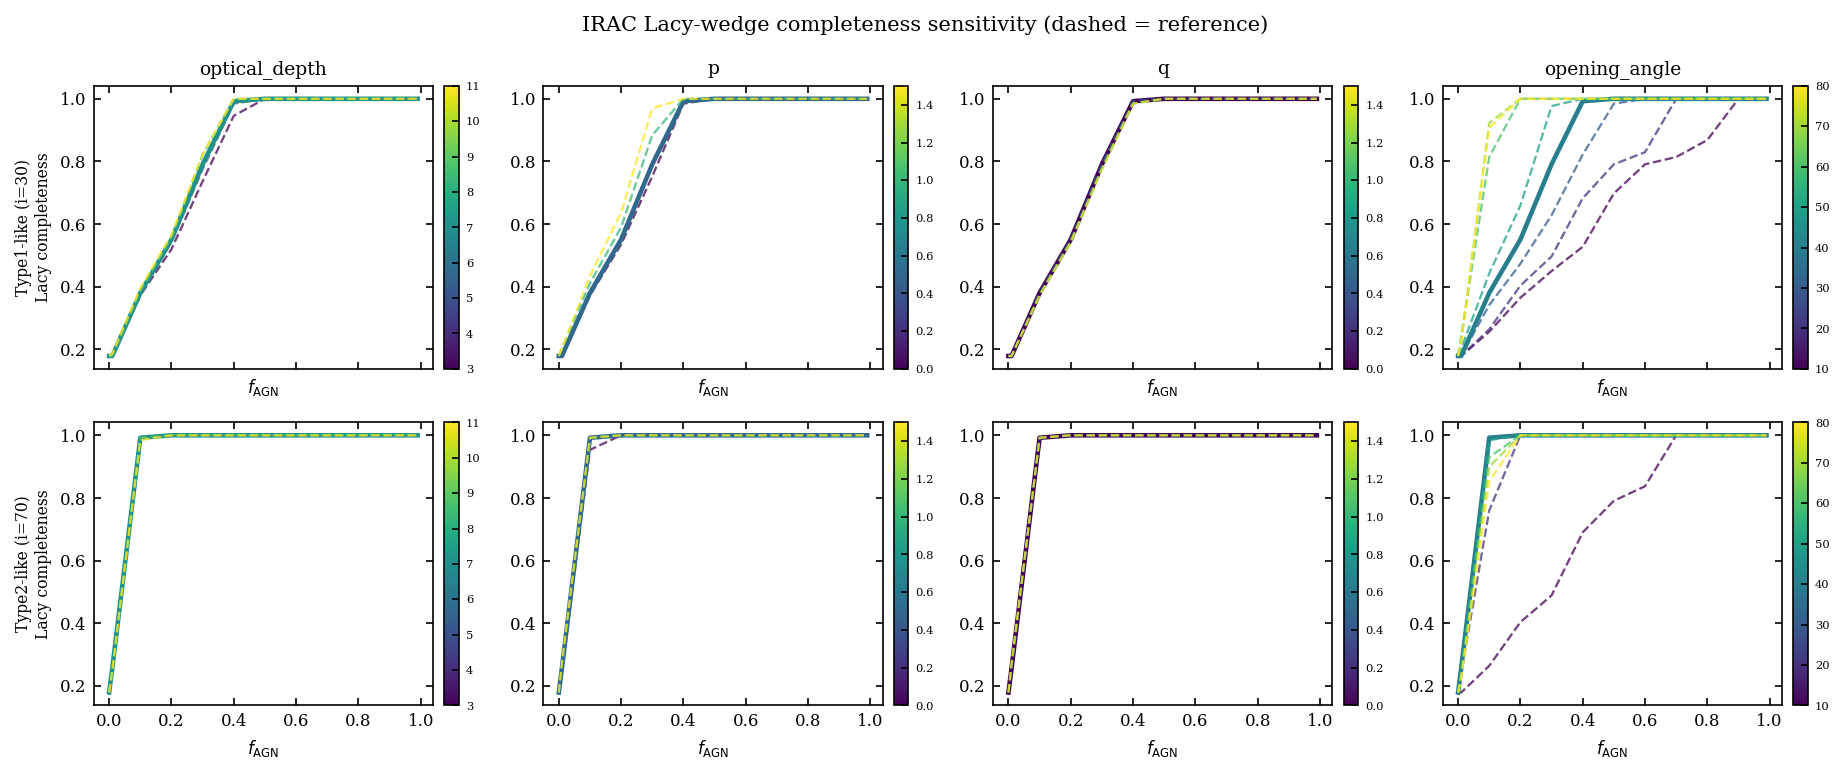

In [6]:
def plot_sensitivity(metric_col, ylabel, title, fname):
    param_names = list(PARAM_GRIDS.keys())
    fig, axes = plt.subplots(2, len(param_names), figsize=(3.1 * len(param_names), 5.2), sharex=True)

    for row, (incl_label, incl) in enumerate(INCLINATIONS.items()):
        for col, param_name in enumerate(param_names):
            ax = axes[row, col]
            grid_values = PARAM_GRIDS[param_name]
            cmap = plt.cm.viridis
            norm = plt.Normalize(vmin=min(grid_values), vmax=max(grid_values))
            for value in grid_values:
                summary_df = results[(incl_label, param_name, value)]
                is_ref = np.isclose(value, REFERENCE[param_name])
                ax.plot(summary_df['f_AGN'], summary_df[metric_col],
                        color=cmap(norm(value)), lw=2.2 if is_ref else 1.1,
                        linestyle='-' if is_ref else '--', alpha=1.0 if is_ref else 0.75)
            if row == 0:
                ax.set_title(param_name, fontsize=9)
            if col == 0:
                ax.set_ylabel(f"{incl_label}\n{ylabel}", fontsize=7.5)
            ax.set_xlabel(r'$f_{\rm AGN}$', fontsize=8)
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])
            cbar = fig.colorbar(sm, ax=ax, fraction=0.08, pad=0.03)
            cbar.ax.tick_params(labelsize=5.5)

    fig.suptitle(title, fontsize=10)
    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=200, bbox_inches='tight')
    plt.show()

plot_sensitivity('irac_completeness', 'Lacy completeness', 'IRAC Lacy-wedge completeness sensitivity (dashed = reference)', 'sensitivity_irac_completeness.pdf')


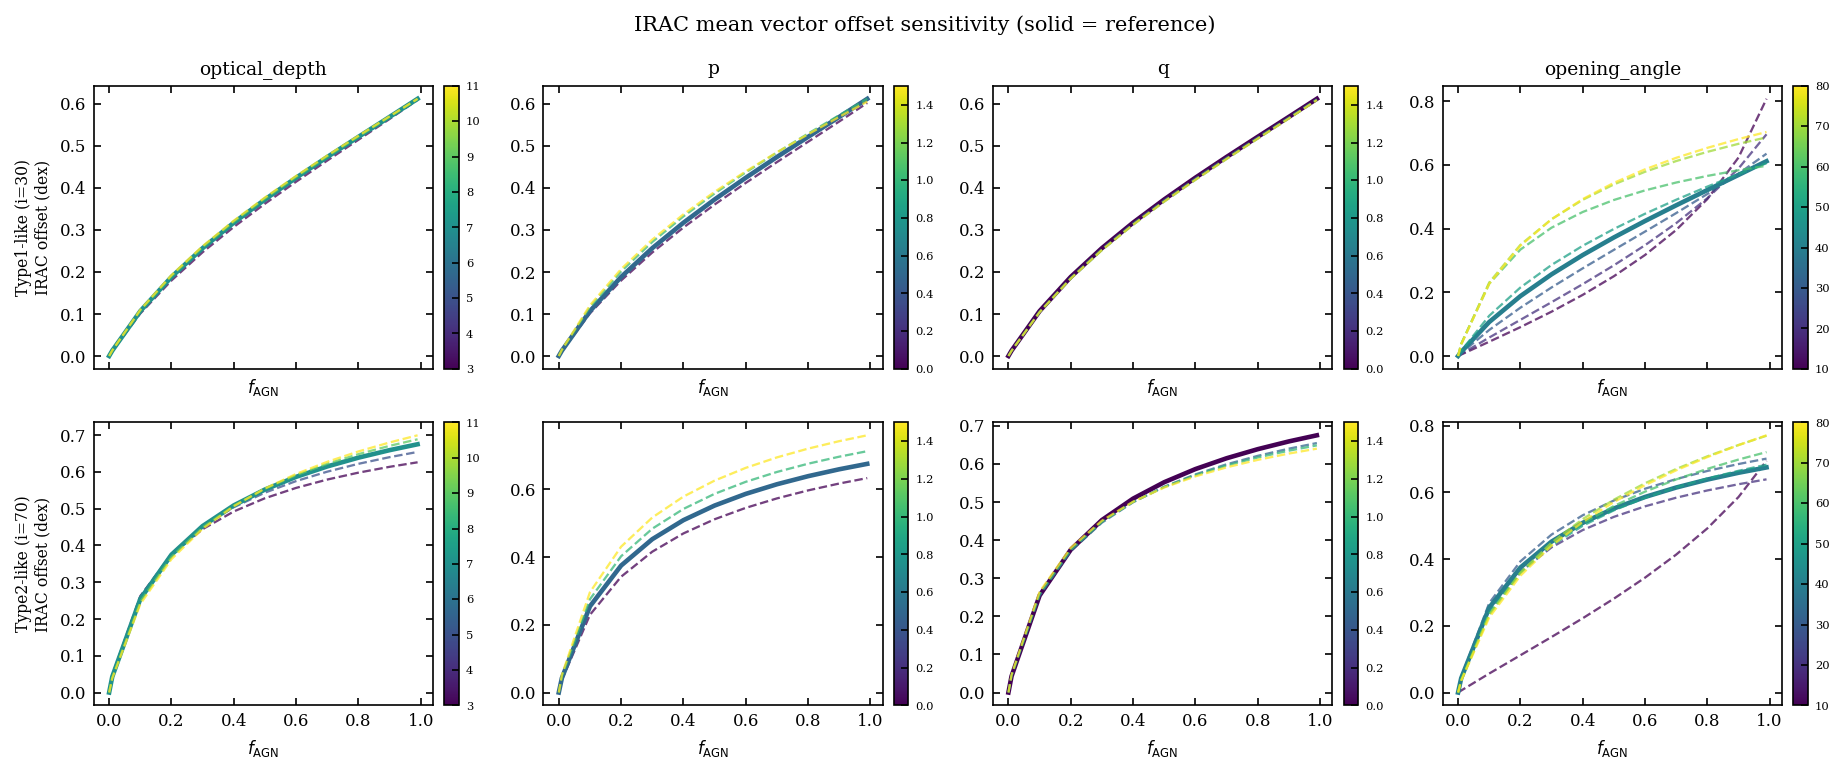

In [7]:
plot_sensitivity('irac_offset_dex', 'IRAC offset (dex)', 'IRAC mean vector offset sensitivity (solid = reference)', 'sensitivity_irac_offset.pdf')


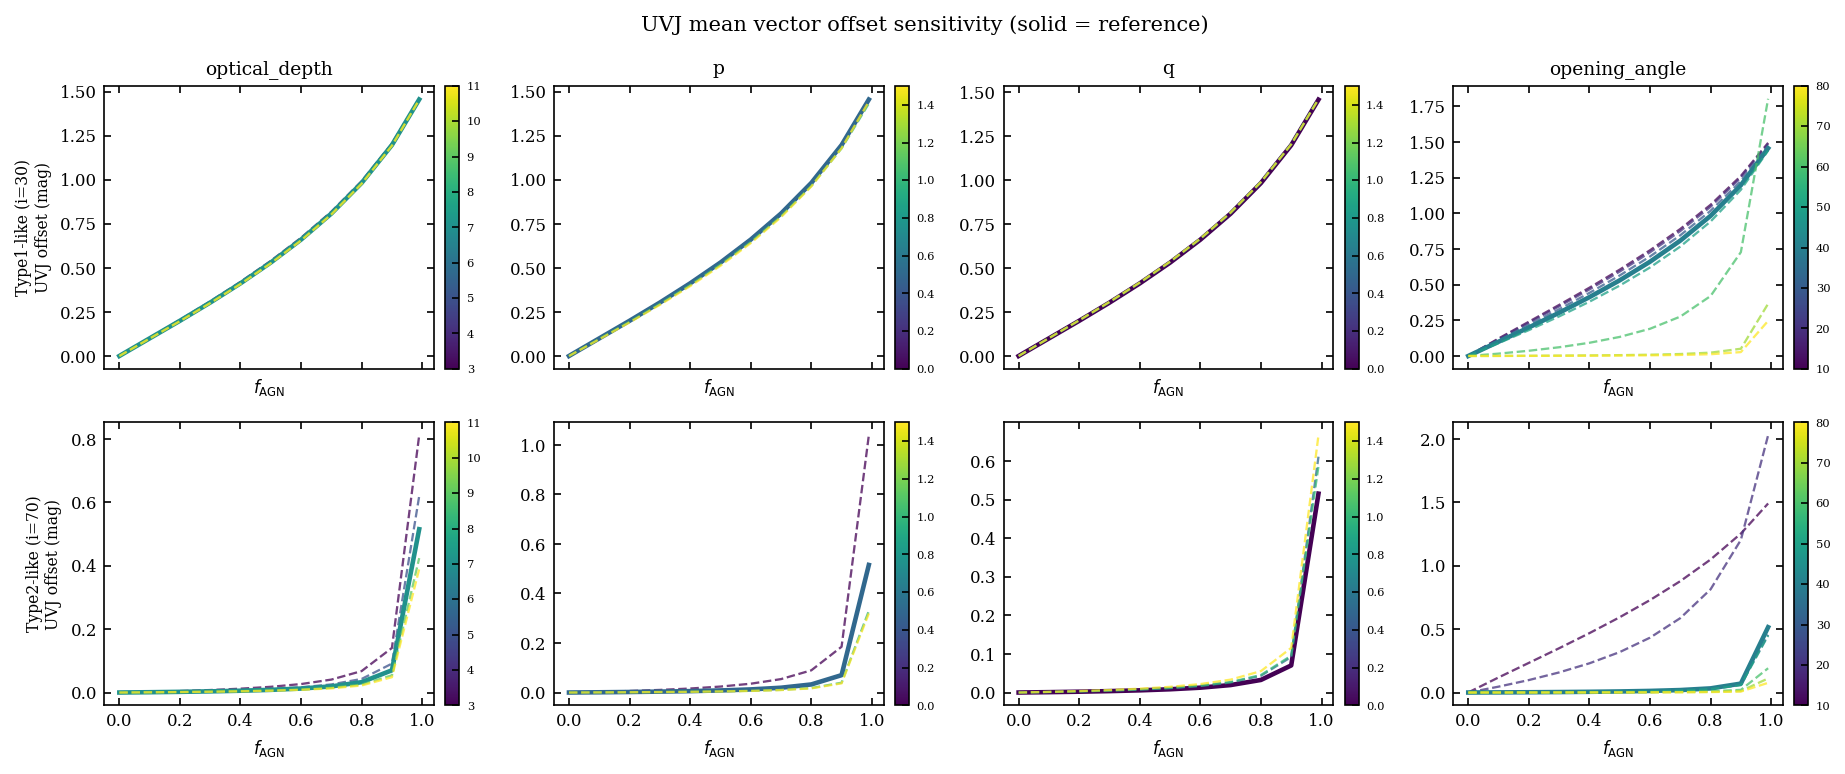

In [8]:
plot_sensitivity('uvj_offset_mag', 'UVJ offset (mag)', 'UVJ mean vector offset sensitivity (solid = reference)', 'sensitivity_uvj_offset.pdf')


## Quantified sensitivity summary

For each parameter, the spread across its grid (at a fixed representative $f_{\rm AGN}$,
e.g. 0.5) relative to the reference value's own result -- a quick numeric answer to
"how much does this parameter actually matter" without eyeballing the plots above.


In [9]:
def sensitivity_table(metric_col, f_agn_check=0.5):
    rows = []
    for incl_label in INCLINATIONS:
        for param_name, grid_values in PARAM_GRIDS.items():
            vals = []
            for value in grid_values:
                summary_df = results[(incl_label, param_name, value)]
                row = summary_df[np.isclose(summary_df['f_AGN'], f_agn_check)]
                vals.append(row[metric_col].values[0])
            ref_val = results[(incl_label, param_name, REFERENCE[param_name])][metric_col]
            ref_val = ref_val[np.isclose(results[(incl_label, param_name, REFERENCE[param_name])]['f_AGN'], f_agn_check)].values[0]
            rows.append({
                'inclination': incl_label, 'parameter': param_name,
                f'{metric_col}_min': min(vals), f'{metric_col}_max': max(vals),
                f'{metric_col}_range': max(vals) - min(vals),
                f'{metric_col}_at_reference': ref_val,
            })
    return pd.DataFrame(rows).sort_values(f'{metric_col}_range', ascending=False)

print(f"=== Sensitivity at f_AGN=0.5 ===\n")
for metric, label in [('irac_completeness', 'IRAC completeness'), ('irac_offset_dex', 'IRAC offset (dex)'), ('uvj_offset_mag', 'UVJ offset (mag)')]:
    print(f"--- {label}: range across each parameter's full grid, sorted by impact ---")
    display(sensitivity_table(metric))
    print()


=== Sensitivity at f_AGN=0.5 ===

--- IRAC completeness: range across each parameter's full grid, sorted by impact ---


,inclination,parameter,irac_completeness_min,irac_completeness_max,irac_completeness_range,irac_completeness_at_reference
3,Type1-like (i=30),opening_angle,0.697674,1.0,0.302326,1.0
7,Type2-like (i=70),opening_angle,0.790698,1.0,0.209302,1.0
1,Type1-like (i=30),p,1.000000,1.0,0.000000,1.0
0,Type1-like (i=30),optical_depth,1.000000,1.0,0.000000,1.0
2,Type1-like (i=30),q,1.000000,1.0,0.000000,1.0
4,Type2-like (i=70),optical_depth,1.000000,1.0,0.000000,1.0
5,Type2-like (i=70),p,1.000000,1.0,0.000000,1.0
6,Type2-like (i=70),q,1.000000,1.0,0.000000,1.0



--- IRAC offset (dex): range across each parameter's full grid, sorted by impact ---


,inclination,parameter,irac_offset_dex_min,irac_offset_dex_max,irac_offset_dex_range,irac_offset_dex_at_reference
7,Type2-like (i=70),opening_angle,0.281298,0.577910,0.296612,0.551617
3,Type1-like (i=30),opening_angle,0.250306,0.543373,0.293067,0.372000
5,Type2-like (i=70),p,0.511152,0.625227,0.114076,0.551617
1,Type1-like (i=30),p,0.359934,0.390089,0.030155,0.372000
4,Type2-like (i=70),optical_depth,0.527985,0.554532,0.026546,0.551617
0,Type1-like (i=30),optical_depth,0.361933,0.376707,0.014774,0.372000
6,Type2-like (i=70),q,0.537707,0.551617,0.013911,0.551617
2,Type1-like (i=30),q,0.366789,0.372000,0.005211,0.372000



--- UVJ offset (mag): range across each parameter's full grid, sorted by impact ---


,inclination,parameter,uvj_offset_mag_min,uvj_offset_mag_max,uvj_offset_mag_range,uvj_offset_mag_at_reference
3,Type1-like (i=30),opening_angle,0.003134,0.605158,0.602024,0.530359
7,Type2-like (i=70),opening_angle,0.000846,0.593853,0.593007,0.008404
1,Type1-like (i=30),p,0.512128,0.533233,0.021106,0.530359
5,Type2-like (i=70),p,0.004256,0.024006,0.019750,0.008404
0,Type1-like (i=30),optical_depth,0.525551,0.539847,0.014296,0.530359
4,Type2-like (i=70),optical_depth,0.005660,0.018009,0.012349,0.008404
6,Type2-like (i=70),q,0.008404,0.014700,0.006296,0.008404
2,Type1-like (i=30),q,0.530359,0.536151,0.005792,0.530359


## Extension: full inclination sweep

The sections above held inclination fixed at the paper's two chosen values (30 deg,
70 deg) and swept the *other* four torus parameters. This section does the
complementary sweep: hold optical depth, p, q, and opening angle at the paper's
reference values, and sweep inclination across its *full* SKIRTOR grid (0 deg to
90 deg in 10 deg steps), to see how the paper's two chosen viewing angles sit within
the full range and whether there's a sharp transition (an obscuration "edge") between
them.


In [10]:
INCLINATION_GRID = sorted({float(re.match(r'.*_i([\d.]+)_sed\.dat', f).group(1))
                            for f in _files if re.match(r'.*_i([\d.]+)_sed\.dat', f)})
print("Full inclination grid:", INCLINATION_GRID)

inclination_results = {}
t0 = time.time()
for incl in INCLINATION_GRID:
    agn_model = load_agn_model({}, incl)  # all four other params at REFERENCE
    df_grid = run_grid_for_agn(agn_model)
    inclination_results[incl] = summarise(df_grid)
print(f"[{time.time()-t0:.1f}s] inclination sweep complete: {len(inclination_results)} values.")

rows = []
for incl, summary_df in inclination_results.items():
    d = summary_df.copy()
    d['inclination'] = incl
    rows.append(d)
inclination_sweep_df = pd.concat(rows, ignore_index=True)
inclination_sweep_df.to_csv(os.path.join(OUTPUT_DIR, 'inclination_sweep_full.csv'), index=False)


Full inclination grid: [0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0]


[8.3s] inclination sweep complete: 10 values.


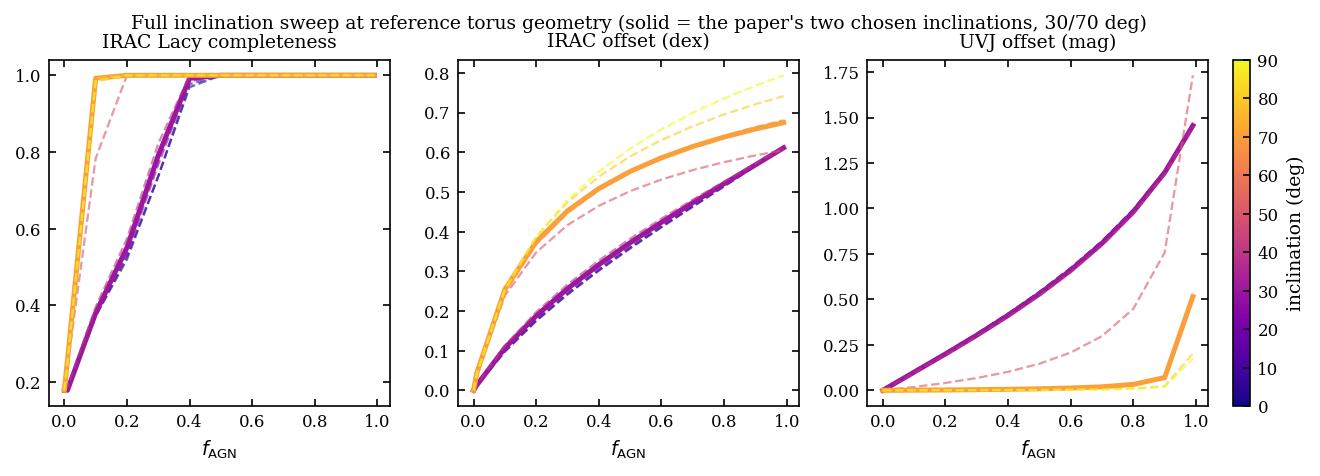

Reference-geometry completeness by inclination at f_AGN=0.5:
  i=   0: IRAC completeness=1.000, UVJ offset=0.541 mag
  i=  10: IRAC completeness=1.000, UVJ offset=0.540 mag
  i=  20: IRAC completeness=1.000, UVJ offset=0.537 mag
  i=  30: IRAC completeness=1.000, UVJ offset=0.530 mag
  i=  40: IRAC completeness=1.000, UVJ offset=0.520 mag
  i=  50: IRAC completeness=1.000, UVJ offset=0.146 mag
  i=  60: IRAC completeness=1.000, UVJ offset=0.009 mag
  i=  70: IRAC completeness=1.000, UVJ offset=0.008 mag
  i=  80: IRAC completeness=1.000, UVJ offset=0.003 mag
  i=  90: IRAC completeness=1.000, UVJ offset=0.002 mag


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.0))
cmap = plt.cm.plasma
norm = plt.Normalize(vmin=0, vmax=90)

for incl in INCLINATION_GRID:
    summary_df = inclination_results[incl]
    is_paper_value = incl in (30.0, 70.0)
    style = dict(lw=2.4 if is_paper_value else 1.1, alpha=1.0 if is_paper_value else 0.6,
                 linestyle='-' if is_paper_value else '--', color=cmap(norm(incl)))
    axes[0].plot(summary_df['f_AGN'], summary_df['irac_completeness'], **style)
    axes[1].plot(summary_df['f_AGN'], summary_df['irac_offset_dex'], **style)
    axes[2].plot(summary_df['f_AGN'], summary_df['uvj_offset_mag'], **style)

axes[0].set_title('IRAC Lacy completeness')
axes[1].set_title('IRAC offset (dex)')
axes[2].set_title('UVJ offset (mag)')
for ax in axes:
    ax.set_xlabel(r'$f_{\rm AGN}$')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.03, pad=0.02, label='inclination (deg)')
fig.suptitle('Full inclination sweep at reference torus geometry (solid = the paper\'s two chosen inclinations, 30/70 deg)', fontsize=9)
fig.savefig(os.path.join(OUTPUT_DIR, 'inclination_sweep.pdf'), dpi=200, bbox_inches='tight')
plt.show()

print("Reference-geometry completeness by inclination at f_AGN=0.5:")
for incl in INCLINATION_GRID:
    row = inclination_results[incl]
    row = row[np.isclose(row['f_AGN'], 0.5)]
    print(f"  i={incl:4.0f}: IRAC completeness={row['irac_completeness'].values[0]:.3f}, "
          f"UVJ offset={row['uvj_offset_mag'].values[0]:.3f} mag")


## Extension: joint inclination x opening-angle map

Opening angle turned out to be by far the most influential of the four "other" torus
parameters (see the sensitivity tables above). Since inclination and opening angle
together are what actually determine whether a given sightline is inside or outside
the torus's obscuring cone, this section maps IRAC completeness and UVJ offset jointly
over both, at two representative AGN luminosity fractions, to see the obscuration
boundary directly rather than as two separate one-parameter-at-a-time slices.


In [12]:
t0 = time.time()
joint_results = {}  # (inclination, opening_angle) -> summary DataFrame
for incl in INCLINATION_GRID:
    for oa in PARAM_GRIDS['opening_angle']:
        agn_model = load_agn_model({'opening_angle': oa}, incl)
        df_grid = run_grid_for_agn(agn_model)
        joint_results[(incl, oa)] = summarise(df_grid)
print(f"[{time.time()-t0:.1f}s] joint sweep complete: {len(joint_results)} (inclination, opening_angle) combinations.")

rows = []
for (incl, oa), summary_df in joint_results.items():
    d = summary_df.copy()
    d['inclination'] = incl
    d['opening_angle'] = oa
    rows.append(d)
joint_sweep_df = pd.concat(rows, ignore_index=True)
joint_sweep_df.to_csv(os.path.join(OUTPUT_DIR, 'inclination_opening_angle_joint.csv'), index=False)


[66.3s] joint sweep complete: 80 (inclination, opening_angle) combinations.


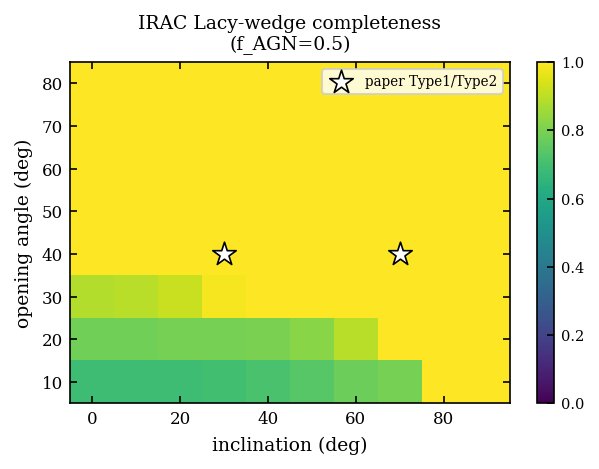

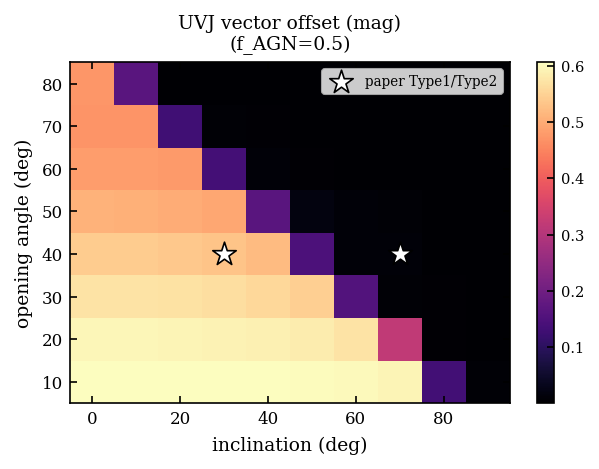

In [13]:
def joint_heatmap(metric_col, f_agn_check, cmap, title, fname, vmin=None, vmax=None):
    incl_vals = INCLINATION_GRID
    oa_vals = PARAM_GRIDS['opening_angle']
    grid = np.full((len(oa_vals), len(incl_vals)), np.nan)
    for i, oa in enumerate(oa_vals):
        for j, incl in enumerate(incl_vals):
            row = joint_results[(incl, oa)]
            row = row[np.isclose(row['f_AGN'], f_agn_check)]
            grid[i, j] = row[metric_col].values[0]

    fig, ax = plt.subplots(figsize=(4.3, 3.2))
    im = ax.pcolormesh(incl_vals, oa_vals, grid, cmap=cmap, shading='nearest', vmin=vmin, vmax=vmax)
    ax.scatter([30, 70], [40, 40], marker='*', s=140, c='white', edgecolors='k', linewidths=0.8, zorder=5,
               label='paper Type1/Type2')
    ax.set_xlabel('inclination (deg)')
    ax.set_ylabel('opening angle (deg)')
    ax.set_title(f'{title}\n(f_AGN={f_agn_check})', fontsize=9)
    ax.legend(fontsize=6.5, loc='upper right')
    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.tick_params(labelsize=7)
    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=200, bbox_inches='tight')
    plt.show()

joint_heatmap('irac_completeness', 0.5, 'viridis', 'IRAC Lacy-wedge completeness', 'joint_irac_completeness_f05.pdf', vmin=0, vmax=1)
joint_heatmap('uvj_offset_mag', 0.5, 'magma', 'UVJ vector offset (mag)', 'joint_uvj_offset_f05.pdf')


## UVJ tracks with propagated systematic error

The sensitivity curves above show *how much* the summary statistics move; this section
shows *where the track actually sits* in the UVJ diagram itself, with the systematic
spread from the torus-geometry sweep (optical depth, p, q, opening angle -- the
`results` dict from the OFAT sweep above, both inclinations) drawn as an error
envelope around the reference track.

**What the envelope means, precisely:** at each $f_{\rm AGN}$ grid point, take the
population-mean $(V\!-\!J, U\!-\!V)$ position from *every* OFAT variant computed above
(21 models per inclination: the reference model, plus each of the four "other"
parameters swept one at a time across its full grid) and take the min/max spread. This
is a one-at-a-time systematic-uncertainty proxy, not a full joint uncertainty region
(that would need the full factorial we decided not to run) -- it answers "how far could
this track move if any single torus parameter were different from the paper's chosen
reference," not "how far could it move if several were different at once." Given
optical depth/p/q showed near-zero individual effect and opening angle was the only
parameter with real leverage (see the sensitivity tables above), this envelope is, in
practice, dominated almost entirely by the opening-angle sweep.


In [14]:
def uvj_envelope(incl_label):
    '''Per-f_AGN mean UVJ position and min/max spread across every OFAT
    variant computed for this inclination (reference + all four swept
    parameters' full grids).'''
    per_fagn = {f_agn: {'UV': [], 'VJ': []} for f_agn in FRAC_AGN_GRID}
    for param_name, grid_values in PARAM_GRIDS.items():
        for value in grid_values:
            summary_df = results[(incl_label, param_name, value)]
            for _, row in summary_df.iterrows():
                per_fagn[row['f_AGN']]['UV'].append(row['mean_UV'])
                per_fagn[row['f_AGN']]['VJ'].append(row['mean_VJ'])

    ref_track = results[(incl_label, 'optical_depth', REFERENCE['optical_depth'])]
    rows = []
    for f_agn in FRAC_AGN_GRID:
        uv_vals = np.array(per_fagn[f_agn]['UV'])
        vj_vals = np.array(per_fagn[f_agn]['VJ'])
        ref_row = ref_track[np.isclose(ref_track['f_AGN'], f_agn)].iloc[0]
        rows.append({
            'f_AGN': f_agn, 'UV_ref': ref_row['mean_UV'], 'VJ_ref': ref_row['mean_VJ'],
            'UV_min': uv_vals.min(), 'UV_max': uv_vals.max(),
            'VJ_min': vj_vals.min(), 'VJ_max': vj_vals.max(),
        })
    return pd.DataFrame(rows)

envelope_type1 = uvj_envelope('Type1-like (i=30)')
envelope_type2 = uvj_envelope('Type2-like (i=70)')
envelope_type1.to_csv(os.path.join(OUTPUT_DIR, 'uvj_envelope_type1.csv'), index=False)
envelope_type2.to_csv(os.path.join(OUTPUT_DIR, 'uvj_envelope_type2.csv'), index=False)
envelope_type1.round(3)


,f_AGN,UV_ref,VJ_ref,UV_min,UV_max,VJ_min,VJ_max
0,0.00,1.605,0.991,1.605,1.605,0.991,0.991
1,0.01,1.595,0.990,1.593,1.605,0.989,0.992
2,0.10,1.509,0.980,1.487,1.605,0.973,1.003
3,0.20,1.412,0.968,1.374,1.605,0.954,1.018
4,0.30,1.313,0.953,1.262,1.605,0.931,1.037
5,0.40,1.209,0.935,1.147,1.605,0.905,1.060
6,0.50,1.097,0.914,1.029,1.605,0.873,1.090
7,0.60,0.974,0.886,0.903,1.605,0.833,1.133
8,0.70,0.837,0.849,0.767,1.604,0.782,1.195
9,0.80,0.678,0.798,0.617,1.604,0.713,1.302


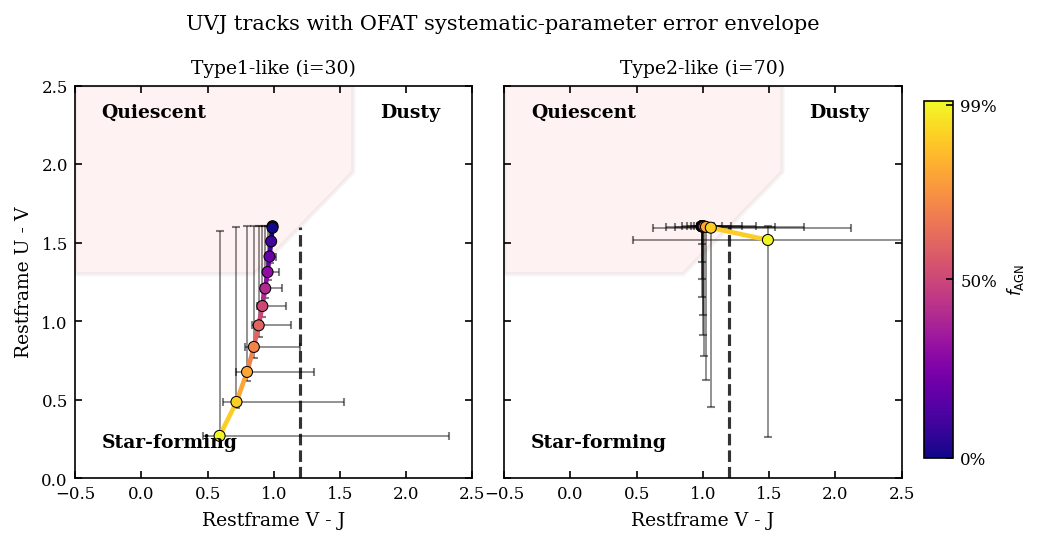

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.4), sharex=True, sharey=True)
cmap = plt.cm.plasma
norm = plt.Normalize(vmin=0, vmax=1)

for ax, (envelope, title) in zip(axes, [(envelope_type1, 'Type1-like (i=30)'), (envelope_type2, 'Type2-like (i=70)')]):
    visualization.plot_uvj_diagram([], [], ax=ax, title=title)

    # Systematic error band: horizontal + vertical error bars at each f_AGN
    # point, sized to the OFAT min/max spread around the reference track.
    xerr = np.vstack([envelope['VJ_ref'] - envelope['VJ_min'], envelope['VJ_max'] - envelope['VJ_ref']])
    yerr = np.vstack([envelope['UV_ref'] - envelope['UV_min'], envelope['UV_max'] - envelope['UV_ref']])
    ax.errorbar(envelope['VJ_ref'], envelope['UV_ref'], xerr=xerr, yerr=yerr,
                fmt='none', ecolor='k', elinewidth=0.8, capsize=2, alpha=0.5, zorder=3)

    for i in range(len(envelope) - 1):
        ax.plot(envelope['VJ_ref'].iloc[i:i+2], envelope['UV_ref'].iloc[i:i+2],
                 color=cmap(norm(envelope['f_AGN'].iloc[i])), lw=2.2, solid_capstyle='round', zorder=4)
    ax.scatter(envelope['VJ_ref'], envelope['UV_ref'], c=[cmap(norm(f)) for f in envelope['f_AGN']],
               s=28, edgecolors='k', linewidths=0.5, zorder=5)

fig.subplots_adjust(right=0.85, wspace=0.08)
axes[1].set_ylabel('')
cbar_ax = fig.add_axes([0.87, 0.15, 0.025, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, ticks=[0, 0.5, 0.99])
cbar.ax.set_yticklabels(['0%', '50%', '99%'])
cbar.set_label(r'$f_{\rm AGN}$', fontsize=8)

fig.suptitle('UVJ tracks with OFAT systematic-parameter error envelope', fontsize=10, y=1.02)
fig.savefig(os.path.join(OUTPUT_DIR, 'uvj_tracks_with_systematic_envelope.pdf'), dpi=200, bbox_inches='tight')
plt.show()
